# Sanity Check

Проверяем, действительно ли самые важные нейроны слоя влияют на чистый person-logit.

Берем ranking по `abs(activation * grad)` из classifier importance cache и строим два типа интервенций:

- `zero`: выбранные нейроны зануляются;
- `opposite_extreme`: если signed importance нейрона положительная, подставляется минимум по слою; если отрицательная, подставляется максимум по слою.

Для каждого шага считаются две кривые: `single_step` меняет только текущий блок нейронов, `cumulative` меняет все нейроны от rank 1 до текущего rank. Шаг sweep везде одинаковый: `0.1%` нейронов. Основной график показывает ненормированный `logit_drop = clean_logit - intervened_logit`, полосу `+-СКО`, AUC и исходный `logit0`. Пунктирная линия `logit0` означает границу `intervened_logit = 0`: если raw drop выше нее, средний intervened logit уже меньше нуля.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "ClassifierDetectorExperiments":
    REPO_ROOT = REPO_ROOT.parent

LAB_ROOT = REPO_ROOT / "classifier_experiments"
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(LAB_ROOT))

from classifier_patch_analysis import ClassifierAttackConfig, ClassifierPatchExperiment, ExperimentConfig
from classifier_patch_analysis.sanity_check import compute_or_load_sanity_check, plot_sanity_check_curves, plot_sanity_check_unsigned_curves
from classifier_patch_analysis.plots import savefig

In [2]:
SEED = 17
IMG_SIZE = 224
MODEL_CHECKPOINT = str(REPO_ROOT / "data" / "yolo11-cls-person.pt")
BASE_WEIGHTS = str(REPO_ROOT / "data" / "yolo11s-cls.pt")
PATCH_PATH = str(REPO_ROOT / "data" / "cls_patch.png")
DATASET_PATH = str(REPO_ROOT / "datasets" / "COCO_people_224")
DEVICE = "auto"
BATCH_SIZE = 64
SUCCESS_DROP_THRESHOLD = 0.5
TARGET_LAYER = "model.9"

N_SUCCESS_EXAMPLES = 10
N_FAIL_EXAMPLES = 10
MAX_PERCENT = 100.0
STEP_PERCENT = 0.1
FORCE = False

attack_config = ClassifierAttackConfig(
    dataset_path=DATASET_PATH,
    patch_path=PATCH_PATH,
    checkpoint_path=MODEL_CHECKPOINT,
    base_weights_path=BASE_WEIGHTS,
    output_dir=str(LAB_ROOT / "outputs" / "classifier_patch_analysis"),
    img_size=IMG_SIZE,
    device=DEVICE,
    success_drop_threshold=SUCCESS_DROP_THRESHOLD,
    inference_batch_size=BATCH_SIZE,
    seed=SEED,
)
exp = ClassifierPatchExperiment(ExperimentConfig(attack=attack_config, target_layer=TARGET_LAYER))
comparison_output = REPO_ROOT / "ClassifierDetectorExperiments" / "outputs"
comparison_output.mkdir(parents=True, exist_ok=True)
exp.output_dir, comparison_output

(PosixPath('/Users/ashentide/PycharmProjects/PatchSuccessResearch/classifier_experiments/outputs/classifier_patch_analysis'),
 PosixPath('/Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs'))

In [3]:
cache = exp.build_or_load_cache(force=False)
print(cache.to_summary())

success_examples = sorted(cache.successes, key=lambda item: item.drop, reverse=True)[:N_SUCCESS_EXAMPLES]
fail_examples = sorted(cache.failures, key=lambda item: item.drop)[:N_FAIL_EXAMPLES]
examples = success_examples + fail_examples

print("selected examples:", len(examples))
print("success/fail:", len(success_examples), len(fail_examples))

{'cache_key': '73a6637a84f10f60', 'n_examples': 5843, 'n_success': 4284, 'n_fail': 1559, 'success_rate': 0.7331850077015232, 'n_failed': 0, 'failed_head': [], 'unbalanced': True}
selected examples: 20
success/fail: 10 10


In [4]:
result = compute_or_load_sanity_check(
    exp,
    examples,
    layer_name=TARGET_LAYER,
    max_percent=MAX_PERCENT,
    step_percent=STEP_PERCENT,
    force=FORCE,
)

rows = result["rows"].copy()
summary = result["summary"].copy()
schedule = result["schedule"].copy()

print("loaded_from_cache:", result["loaded_from_cache"])
print("cache:", result["cache_path"])
print("layer:", result["layer_name"], "shape CHW:", result["activation_shape_chw"], "neurons:", result["n_neurons"])
print("steps:", len(schedule), "max percent:", result["max_percent"], "step percent:", result["step_percent"])
print("baseline logit mean/std:", rows["mean_baseline_logit"].iloc[0], rows["std_baseline_logit"].iloc[0])
display(schedule.head(20))

loaded_from_cache: False
cache: /Users/ashentide/PycharmProjects/PatchSuccessResearch/classifier_experiments/outputs/classifier_patch_analysis/cache/sanity_check_a5332e4aa5c34a87.pkl
layer: model.9 shape CHW: (512, 7, 7) neurons: 25088
steps: 965 max percent: 100.0 step percent: 0.1
baseline logit mean/std: 2.3431790590286257 5.06503776519044


,step,start_rank,end_rank,n_changed,changed_frac,changed_percent,step_size
0,1,1,26,26,0.001036,0.103635,26
1,2,27,52,52,0.002073,0.207270,26
2,3,53,78,78,0.003109,0.310906,26
3,4,79,104,104,0.004145,0.414541,26
4,5,105,130,130,0.005182,0.518176,26
5,6,131,156,156,0.006218,0.621811,26
6,7,157,182,182,0.007254,0.725446,26
7,8,183,208,208,0.008291,0.829082,26
8,9,209,234,234,0.009327,0.932717,26
9,10,235,260,260,0.010364,1.036352,26


In [5]:
display(
    summary[
        [
            "intervention", "curve",
            "auc_mean_logit_drop", "auc_mean_abs_logit_drop",
            "final_mean_logit_drop", "final_std_logit_drop",
            "mean_baseline_logit", "std_baseline_logit",
            "final_changed_percent", "n_steps",
        ]
    ]
)
display(rows.head(30))

,intervention,curve,auc_mean_logit_drop,auc_mean_abs_logit_drop,final_mean_logit_drop,final_std_logit_drop,mean_baseline_logit,std_baseline_logit,final_changed_percent,n_steps
0,zero,single_step,0.004064,0.014451,0.000760,0.001579,2.343179,5.065038,100.0,965
1,zero,cumulative,1.848697,4.933527,1.260519,5.065038,2.343179,5.065038,100.0,965
2,opposite_extreme,single_step,1.679513,1.682935,0.702303,0.299539,2.343179,5.065038,100.0,965
3,opposite_extreme,cumulative,85.301218,86.205774,-5.720411,6.834396,2.343179,5.065038,100.0,965


,intervention,curve,step,start_rank,end_rank,step_size,n_changed,changed_frac,changed_percent,source,...,median_logit_drop,mean_abs_logit_drop,std_abs_logit_drop,median_abs_logit_drop,mean_normalized_drop,std_normalized_drop,median_normalized_drop,mean_intervened_logit,mean_baseline_logit,std_baseline_logit
0,zero,single_step,1,1,26,26,26,0.001036,0.103635,classifier,...,1.432405,1.313198,0.399382,1.432405,0.153092,0.216212,0.251091,1.509495,2.343179,5.065038
1,zero,cumulative,1,1,26,26,26,0.001036,0.103635,classifier,...,1.432405,1.313198,0.399382,1.432405,0.153092,0.216212,0.251091,1.509495,2.343179,5.065038
2,zero,single_step,2,27,52,26,52,0.002073,0.207270,classifier,...,1.297535,1.113825,0.422133,1.297535,0.144221,0.178142,0.217638,1.565566,2.343179,5.065038
3,zero,cumulative,2,27,52,26,52,0.002073,0.207270,classifier,...,2.720104,2.421150,0.812718,2.720104,0.295900,0.393049,0.467793,0.739316,2.343179,5.065038
4,zero,single_step,3,53,78,26,78,0.003109,0.310906,classifier,...,0.522043,0.518339,0.269045,0.549034,0.055689,0.091942,0.096174,2.038124,2.343179,5.065038
5,zero,cumulative,3,53,78,26,78,0.003109,0.310906,classifier,...,3.083406,2.875720,0.922798,3.083406,0.332209,0.472227,0.560410,0.535581,2.343179,5.065038
6,zero,single_step,4,79,104,26,104,0.004145,0.414541,classifier,...,0.345815,0.360414,0.243623,0.376303,0.046749,0.063056,0.071770,2.088310,2.343179,5.065038
7,zero,cumulative,4,79,104,26,104,0.004145,0.414541,classifier,...,3.196410,3.184079,1.072061,3.354693,0.363396,0.523526,0.630409,0.362738,2.343179,5.065038
8,zero,single_step,5,105,130,26,130,0.005182,0.518176,classifier,...,-0.022597,0.120963,0.107697,0.091236,0.000124,0.030139,-0.005220,2.334579,2.343179,5.065038
9,zero,cumulative,5,105,130,26,130,0.005182,0.518176,classifier,...,3.197319,3.248624,1.067423,3.378956,0.364535,0.535270,0.640089,0.349561,2.343179,5.065038


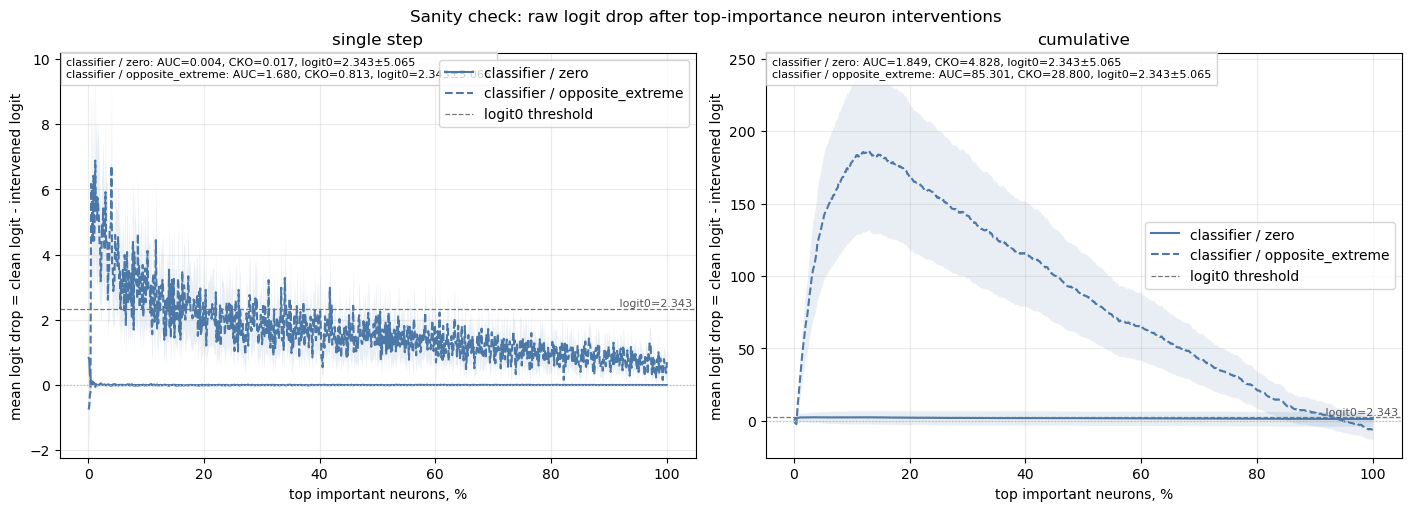

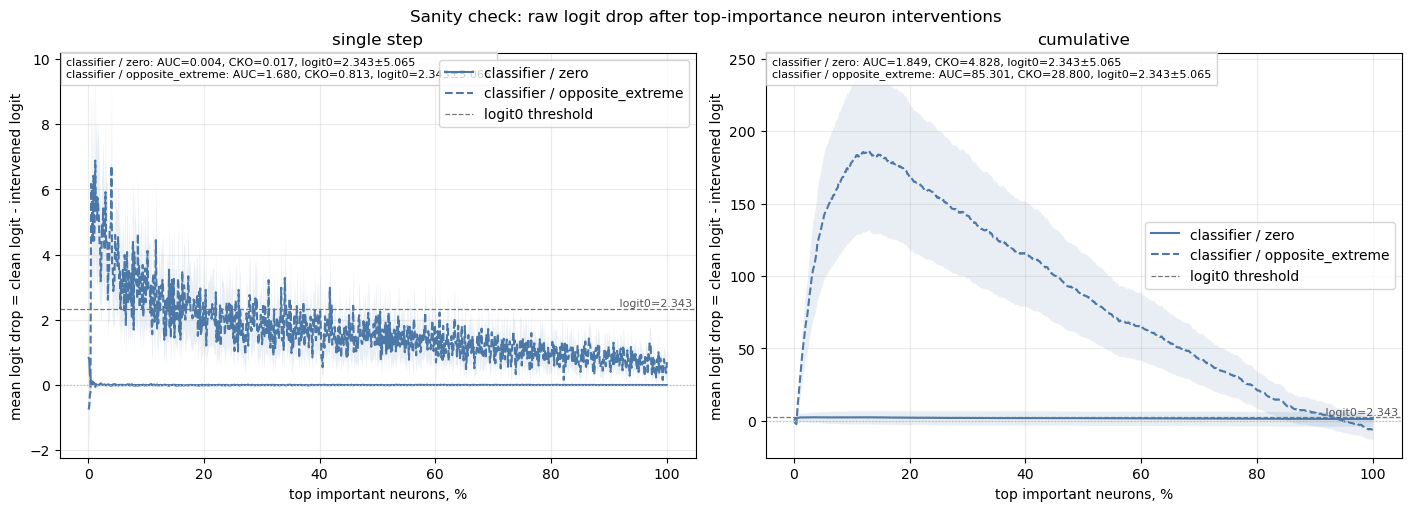

In [6]:
fig = plot_sanity_check_curves(rows)
savefig(fig, comparison_output / "sanity_check_raw_logit_drop_curves.png")
fig

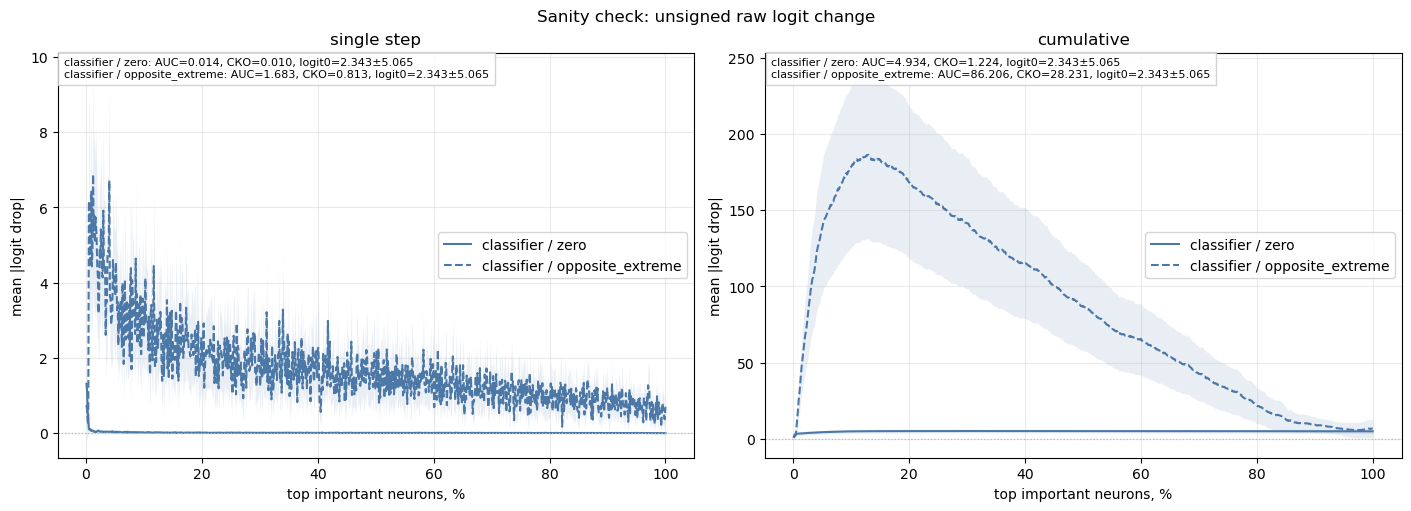

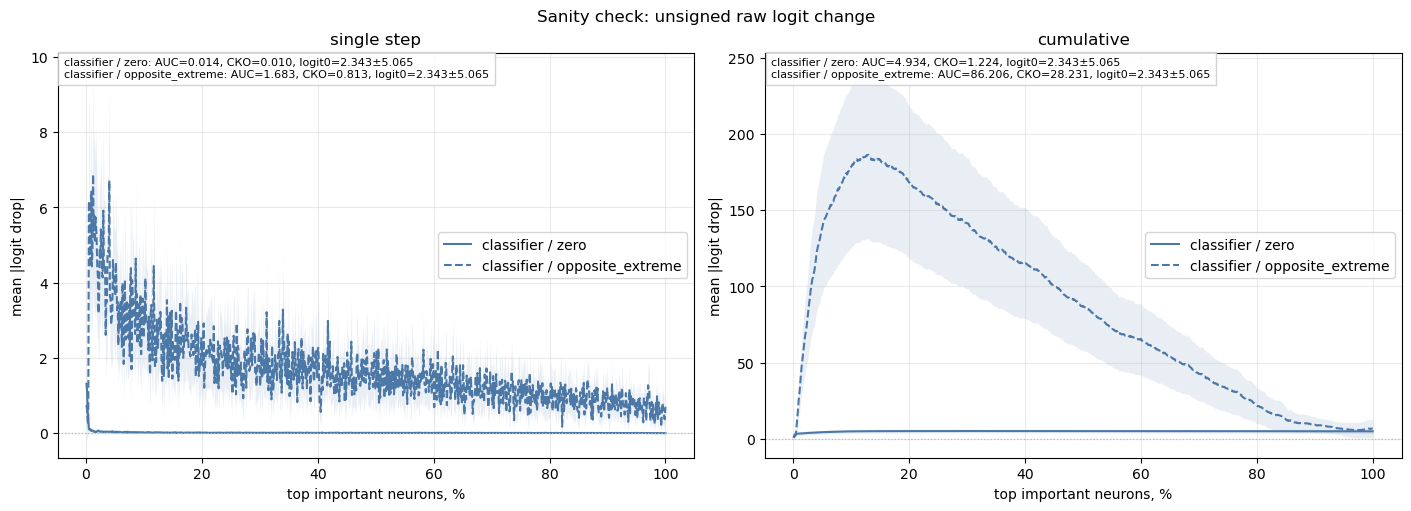

In [7]:
fig_unsigned = plot_sanity_check_unsigned_curves(rows)
savefig(fig_unsigned, comparison_output / "sanity_check_unsigned_logit_drop_curves.png")
fig_unsigned

In [ ]:
rows.to_csv(comparison_output / "sanity_check_rows.csv", index=False)
summary.to_csv(comparison_output / "sanity_check_summary.csv", index=False)
schedule.to_csv(comparison_output / "sanity_check_schedule.csv", index=False)
print("saved to:", comparison_output)

saved to: /Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs


: 